In [1]:
%%capture
!pip install transformers datasets seqeval accelerate torch numpy
!pip install --upgrade transformers

In [2]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
)

In [3]:
# ==========================================
# 1. Load Dataset & Extract Labels
# ==========================================
# MedMentions-ZS is available directly on the Hub
dataset = load_dataset("Ben10x/MedMentions-MTI881-NER")

# The dataset stores tags as strings (e.g., 'B-T062', 'I-T062', 'O').
# We need to extract all unique tags to create our label mappings.
# Note: Adjust the column names 'tokens' and 'ner_tags' if the dataset uses different keys.
unique_tags = set()
for split in dataset.keys():
    for row in dataset[split]["ner_tags"]:
        unique_tags.update(row)

label_list = sorted(list(unique_tags))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

# ==========================================
# 2. Tokenization & Label Alignment
# ==========================================
model_id = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_id)

def tokenize_and_align_labels(examples):
    # Tokenize the pre-split words
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=512
    )

    labels = []
    for i, label_sequence in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Special tokens (like [CLS] and [SEP]) map to None. We set their label to -100 so they are ignored in the loss function.
            if word_idx is None:
                label_ids.append(-100)
            # Only label the first token of a given word.
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label_sequence[word_idx]])
            # For subsequent tokens of the same word, also assign -100 (or you can assign the I- tag).
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Apply to train, validation, and test splits
tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/2924 [00:00<?, ? examples/s]

In [12]:
# ==========================================
# 3. Exploratory Data Analysis
# ==========================================

# Flatten all tags into a single list
all_tags = [tag for sublist in dataset['train']['ner_tags'] for tag in sublist]

# Create a frequency table
tag_counts = pd.Series(all_tags).value_counts()

# Separate 'O' from entities
o_count = tag_counts.get('O', 0)
entity_count = tag_counts.sum() - o_count

print(f"Number of unique tags: {len(tag_counts)}")
print(f"Total 'O' tags: {o_count}")
print(f"Total Entity tags: {entity_count}")
print(f"Percentage of 'O' tags: {o_count/tag_counts.sum()*100:.2f}%")

Number of unique tags: 105
Total 'O' tags: 492005
Total Entity tags: 154806
Percentage of 'O' tags: 76.07%


In [13]:
# Table for the 10 most frequent tags, excluding 'O'
top_10_tags = tag_counts.drop('O').head(10)
print(top_10_tags)

B-T038    20103
B-T103    17845
I-T038    12515
B-T058    11835
I-T103    11233
B-T017    10129
I-T058     9688
B-T033     8009
I-T017     6070
B-T082     6069
Name: count, dtype: int64


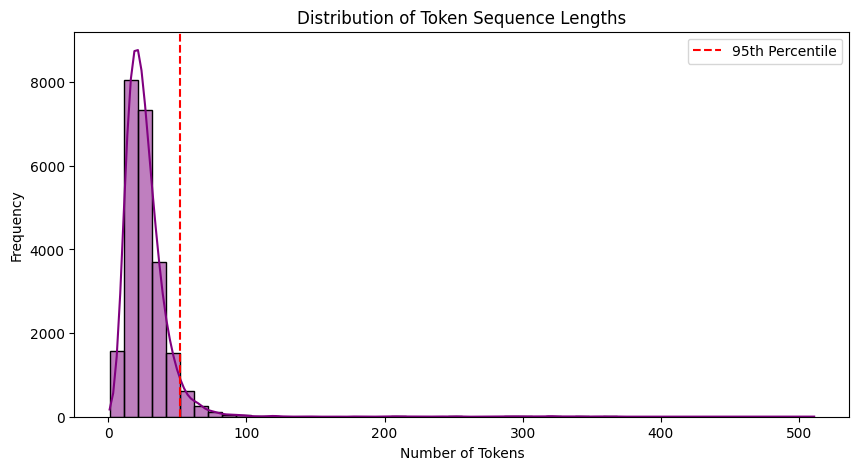

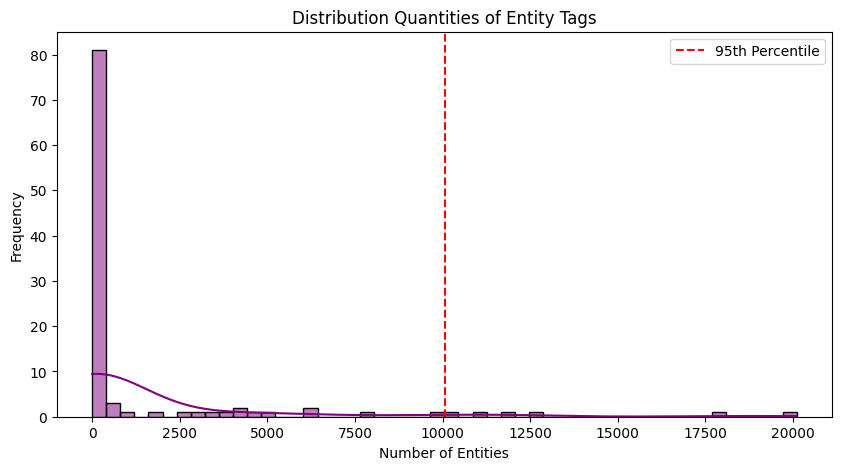

In [18]:
# Distribution of Token Sequence Lengths
seq_lengths = [len(tokens) for tokens in dataset['train']['tokens']]
plt.figure(figsize=(10, 5))
sns.histplot(seq_lengths, bins=50, kde=True, color='purple')
plt.title('Distribution of Token Sequence Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='dashed', label='95th Percentile')
plt.legend()
plt.show()

# Distribution of Entity Tags Quantities, excluding dominating tag 'O'
tag_counts_without_o = tag_counts.drop('O')
plt.figure(figsize=(10, 5))
sbs = sns.histplot(tag_counts_without_o, bins=50, kde=True, color='purple')
plt.title('Distribution Quantities of Entity Tags')
plt.xlabel('Number of Entities')
plt.ylabel('Frequency')
plt.axvline(np.percentile(tag_counts_without_o, 95), color='red', linestyle='dashed', label='95th Percentile')
plt.legend()
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

# 1. Sequence Length Distribution


# 2. Calculate Exact Class Weights for Training
all_tags_flat = [tag for sublist in dataset['train']['ner_tags'] for tag in sublist]
tag_counts = pd.Series(all_tags_flat).value_counts()

num_classes = len(label_list)
total_samples = tag_counts.sum()

# Formula: Total Samples / (Number of Classes * Samples per Class)
class_weights_dict = {
    tag: total_samples / (num_classes * count)
    for tag, count in tag_counts.items()
}

# Map to the label2id order so we can pass it directly to PyTorch
class_weights = [class_weights_dict.get(id2label[i], 1.0) for i in range(num_classes)]

print("Top 5 highest weights (Rarest classes):", sorted(class_weights, reverse=True)[:5])
print("Weight for 'O' class:", class_weights_dict.get('O', 1.0))

Top 5 highest weights (Rarest classes): [np.float64(5988.990740740741), np.float64(5988.990740740741), np.float64(5988.990740740741), np.float64(5988.990740740741), np.float64(5988.990740740741)]
Weight for 'O' class: 0.012172621702504528
